In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)
plt.rcParams['figure.figsize'] = (12, 4)

DB_DIR = Path(os.environ.get('SUJET2_DB_DIR', 'db'))
OUT_DIR = Path(os.environ.get('SUJET2_OUT_DIR', 'output'))
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'sitehist': DB_DIR / 'sitehist.csv',
    'sitepred': DB_DIR / 'sitepred.csv',
    'siteweath': DB_DIR / 'siteweath.csv',
    'zonehist': DB_DIR / 'zonehist.csv',
    'zonepred': DB_DIR / 'zonepred.csv'
}

def read_semicolon_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=';', quotechar='"', encoding='utf-8', engine='python')

raw = {}
for k, p in paths.items():
    if p.exists():
        raw[k] = read_semicolon_csv(p)
        print(k, 'loaded', raw[k].shape)
    else:
        print(k, 'missing', p)

sitehist loaded (3492, 15)
sitepred loaded (3573, 9)
siteweath loaded (4184, 15)
zonehist loaded (21048, 16)
zonepred loaded (20237, 10)


In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().strip('"') for c in df.columns]
    lower_map = {c.lower(): c for c in df.columns}

    def rename_if_present(target: str, *candidates: str):
        for cand in candidates:
            if cand in lower_map:
                df.rename(columns={lower_map[cand]: target}, inplace=True)
                break

    rename_if_present('siteId', 'siteid', 'site_id', 'site id')
    rename_if_present('zoneId', 'zoneid', 'zone_id', 'zone id')
    rename_if_present('dtUpdate', 'dtupdate', 'dt_update', 'dt update')
    return df


def to_day(s):
    return pd.to_datetime(s, errors='coerce').dt.floor('D')

sitehist_raw = normalize_columns(raw.get('sitehist', pd.DataFrame()))
sitepred_raw = normalize_columns(raw.get('sitepred', pd.DataFrame()))
siteweath_raw = normalize_columns(raw.get('siteweath', pd.DataFrame()))
zonehist_raw = normalize_columns(raw.get('zonehist', pd.DataFrame()))
zonepred_raw = normalize_columns(raw.get('zonepred', pd.DataFrame()))

sitehist = sitehist_raw.copy()
sitepred = sitepred_raw.copy()
siteweath = siteweath_raw.copy()
zonehist = zonehist_raw.copy()
zonepred = zonepred_raw.copy()

if 'dtUpdate' in sitehist.columns and 'date' not in sitehist.columns:
    sitehist['date'] = to_day(sitehist['dtUpdate'])
if 'date' in sitepred.columns:
    sitepred['date'] = to_day(sitepred['date'])
if 'dtUpdate' in siteweath.columns and 'date' not in siteweath.columns:
    siteweath['date'] = to_day(siteweath['dtUpdate'])
if 'dtUpdate' in zonehist.columns and 'date' not in zonehist.columns:
    zonehist['date'] = to_day(zonehist['dtUpdate'])
if 'date' in zonepred.columns:
    zonepred['date'] = to_day(zonepred['date'])

for df in (sitehist, sitepred, siteweath, zonehist, zonepred):
    if 'siteId' in df.columns:
        df['siteId'] = pd.to_numeric(df['siteId'], errors='coerce').astype('Int64')
    if 'zoneId' in df.columns:
        df['zoneId'] = pd.to_numeric(df['zoneId'], errors='coerce').astype('Int64')
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.floor('D')

print('keys ok:', 'siteId' in sitehist.columns, 'date' in sitehist.columns)

keys ok: True True


In [3]:
ZERO_OR_NEG_IS_MISSING = {
    'elecTotalKwh': True,
    'totalKwh': True,
    'waterM3': True,
    'totalWater': True
}

UNIT_FIX_RULES_FALLBACK = {
    'elecTotalKwh': [1000, 1_000_000],
    'totalKwh': [1000, 1_000_000],
    'waterM3': [1000],
    'totalWater': [1000]
}

UNIT_FIX_PRED = {
    'site': {
        'elecTotalKwh': 'totalKwh',
        'waterM3': 'totalWater'
    },
    'zone': {
        'elecTotalKwh': 'totalKwh',
        'waterM3': 'totalWater'
    }
}

UNIT_FIX_CANDIDATES = [1000, 1_000_000]
UNIT_FIX_TOL = 3.0
UNIT_FIX_MIN_PAIRS = 20
UNIT_FIX_MIN_PROP = 0.6

CUMUL_SPIKE = {
    'min_missing_run': 3,
    'spike_factor': 20.0,
    'strategy': 'spread',
    'baseline_points': 30,
    'max_spread_days': 370
}

MEASURE_COLS_SITEHIST = [c for c in ['elecTotalKwh', 'waterM3', 'elecCvcKwh', 'elecBveKwh', 'elecLightingKwh', 'elecForceKwh', 'elecAggregatedKwh'] if c in sitehist.columns]
MEASURE_COLS_ZONEHIST = [c for c in ['elecTotalKwh', 'waterM3', 'elecCvcKwh', 'elecBveKwh', 'elecLightingKwh', 'elecForceKwh', 'elecAggregatedKwh', 'indoorTempDegC'] if c in zonehist.columns]
MEASURE_COLS_SITEPRED = [c for c in ['totalKwh', 'totalWater', 'tempAmb'] if c in sitepred.columns]
MEASURE_COLS_ZONEPRED = [c for c in ['totalKwh', 'totalWater', 'tempAmb'] if c in zonepred.columns]

print('measure cols sitehist', MEASURE_COLS_SITEHIST)

measure cols sitehist ['elecTotalKwh', 'waterM3', 'elecCvcKwh', 'elecBveKwh', 'elecLightingKwh', 'elecForceKwh', 'elecAggregatedKwh']


In [4]:
def _num(s):
    return pd.to_numeric(s, errors='coerce')


def apply_missing_sentinels(df: pd.DataFrame, cols, rule_map: dict) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        x = _num(df[c])
        if rule_map.get(c, False):
            x = x.mask(x <= 0, np.nan)
        else:
            x = x.mask(x < 0, np.nan)
        df[c] = x
    return df


def fix_unit_by_predictions(hist_df: pd.DataFrame, pred_df: pd.DataFrame, group_cols, date_col: str, hist_col: str, pred_col: str, candidates, tol=3.0, min_pairs=20, min_prop=0.6):
    hist_df = hist_df.copy()
    if hist_col not in hist_df.columns or pred_col not in pred_df.columns:
        return hist_df, pd.DataFrame([])

    join_cols = list(group_cols) + [date_col]
    h = hist_df[join_cols + [hist_col]].copy()
    p = pred_df[join_cols + [pred_col]].copy()

    h[hist_col] = _num(h[hist_col])
    p[pred_col] = _num(p[pred_col])

    h = h.dropna(subset=join_cols)
    p = p.dropna(subset=join_cols)
    m = h.merge(p, on=join_cols, how='inner')
    m = m[(m[hist_col] > 0) & (m[pred_col] > 0)]

    if len(m) < min_pairs:
        return hist_df, pd.DataFrame([])

    logs = []
    gobj = m.groupby(group_cols, dropna=False)

    for keys, g in gobj:
        if not isinstance(keys, tuple):
            keys = (keys,)
        ratio = (g[hist_col].to_numpy(dtype=float) / g[pred_col].to_numpy(dtype=float))
        ratio = ratio[np.isfinite(ratio) & (ratio > 0)]
        if len(ratio) < min_pairs:
            continue

        med_ratio = float(np.nanmedian(ratio))
        if not np.isfinite(med_ratio) or med_ratio <= 0:
            continue

        scores = {}
        scores[1.0] = abs(np.log10(med_ratio))
        for d in candidates:
            scores[float(d)] = abs(np.log10(med_ratio / float(d)))

        best_d = min(scores, key=lambda k: scores[k])
        if best_d == 1.0:
            continue

        score0 = scores[1.0]
        scoreb = scores[best_d]
        if not (np.isfinite(scoreb) and scoreb < np.log10(tol) and scoreb + 0.15 < score0):
            continue

        sub_ratio = (g[hist_col].to_numpy(dtype=float) / g[pred_col].to_numpy(dtype=float))
        ok = np.isfinite(sub_ratio) & (sub_ratio > 0)
        sub_ratio = sub_ratio[ok]
        close = np.abs(np.log10(sub_ratio / best_d)) <= np.log10(tol)
        prop_close = float(np.mean(close)) if len(close) else 0.0

        mask_group = np.ones(len(hist_df), dtype=bool)
        for c, v in zip(group_cols, keys):
            mask_group &= (hist_df[c] == v)

        if prop_close >= min_prop:
            mask_apply = mask_group & (hist_df[hist_col].notna()) & (hist_df[hist_col] > 0)
        else:
            join_keys = g[join_cols].drop_duplicates()
            idx_apply = hist_df.loc[mask_group].merge(join_keys, on=join_cols, how='inner').index
            mask_apply = hist_df.index.isin(idx_apply) & (hist_df[hist_col].notna()) & (hist_df[hist_col] > 0)

        if mask_apply.any():
            hist_df.loc[mask_apply, hist_col] = _num(hist_df.loc[mask_apply, hist_col]) / best_d
            logs.append({
                'group': keys,
                'hist_col': hist_col,
                'pred_col': pred_col,
                'chosen_divisor': float(best_d),
                'pairs': int(len(ratio)),
                'median_ratio_hist_over_pred': float(med_ratio),
                'score_before': float(score0),
                'score_after': float(scoreb),
                'prop_close': float(prop_close),
                'applied_rows': int(mask_apply.sum())
            })

    return hist_df, pd.DataFrame(logs)


def fix_unit_outliers_fallback(df: pd.DataFrame, group_cols, value_col: str, divisors, factor=200.0, min_med=1e-9):
    df = df.copy()
    log = []
    if value_col not in df.columns:
        return df, pd.DataFrame(log)

    df[value_col] = _num(df[value_col])

    med = (df.loc[df[value_col].notna() & (df[value_col] > 0)]
             .groupby(group_cols)[value_col].median())
    med_map = med.to_dict()

    vals = df[value_col].to_numpy()
    new_vals = vals.copy()

    for i in range(len(df)):
        v = vals[i]
        if not np.isfinite(v) or v <= 0:
            continue
        k = tuple(df.iloc[i][group_cols].values.tolist())
        m = med_map.get(k, np.nan)
        if not np.isfinite(m) or m < min_med:
            continue
        if v / m <= factor:
            continue

        best = None
        best_ratio = v / m
        for d in divisors:
            vd = v / d
            rd = vd / m
            if rd < best_ratio:
                best_ratio = rd
                best = (d, vd)
        if best is not None and best_ratio <= factor:
            d, vd = best
            new_vals[i] = vd
            log.append({'value_col': value_col, 'group': k, 'index': int(i), 'old': float(v), 'new': float(vd), 'divisor': int(d)})

    df[value_col] = new_vals
    return df, pd.DataFrame(log)


def spread_cumul_spikes_v2(df: pd.DataFrame, group_cols, date_col: str, value_col: str, cfg: dict):
    df = df.copy()
    logs = []
    if value_col not in df.columns or date_col not in df.columns:
        return df, pd.DataFrame(logs)

    df[value_col] = _num(df[value_col])

    min_run = int(cfg.get('min_missing_run', 3))
    spike_factor = float(cfg.get('spike_factor', 20.0))
    strategy = cfg.get('strategy', 'spread')
    baseline_points = int(cfg.get('baseline_points', 30))
    max_spread_days = int(cfg.get('max_spread_days', 370))

    out_parts = []
    for keys, g in df.groupby(group_cols, dropna=False):
        g = g.sort_values(date_col)
        if g[date_col].isna().all():
            out_parts.append(g)
            continue

        idx = pd.date_range(g[date_col].min(), g[date_col].max(), freq='D')
        g2 = g.set_index(date_col).reindex(idx)
        g2.index.name = date_col

        if not isinstance(keys, tuple):
            keys = (keys,)
        for c, v in zip(group_cols, keys):
            g2[c] = v

        x = g2[value_col].copy()
        valid = x.notna() & (x > 0)
        is_missing = ~valid

        overall_med = float(np.nanmedian(x[valid].to_numpy())) if valid.any() else np.nan

        last_valid_pos = np.full(len(x), -1, dtype=int)
        last = -1
        for i in range(len(x)):
            last_valid_pos[i] = last
            if valid.iloc[i]:
                last = i

        for i in range(len(x)):
            v = x.iloc[i]
            if not np.isfinite(v) or v <= 0:
                continue
            prev = last_valid_pos[i]
            if prev < 0:
                continue
            gap = i - prev - 1
            if gap < min_run:
                continue

            prev_vals = x.iloc[:prev + 1]
            prev_valid = prev_vals[prev_vals.notna() & (prev_vals > 0)]
            baseline = float(np.nanmedian(prev_valid.tail(baseline_points).to_numpy())) if len(prev_valid) else np.nan
            if not np.isfinite(baseline) or baseline <= 0:
                baseline = overall_med
            if not np.isfinite(baseline) or baseline <= 0:
                continue

            if v <= spike_factor * baseline:
                continue

            span = gap + 1
            action = strategy
            if span > max_spread_days and strategy == 'spread':
                action = 'drop'

            if action == 'drop':
                x.iloc[i] = np.nan
                logs.append({'group': keys, 'value_col': value_col, 'date': str(g2.index[i].date()), 'action': 'drop', 'old': float(v), 'gap_days': int(gap), 'span_days': int(span), 'baseline': float(baseline)})
            else:
                per_day = v / span
                start = i - gap
                for j in range(start, i + 1):
                    if j == i or is_missing.iloc[j]:
                        x.iloc[j] = per_day
                logs.append({'group': keys, 'value_col': value_col, 'date': str(g2.index[i].date()), 'action': 'spread', 'old': float(v), 'new_per_day': float(per_day), 'gap_days': int(gap), 'span_days': int(span), 'baseline': float(baseline)})

        g2[value_col] = x
        out_parts.append(g2.reset_index())

    out = pd.concat(out_parts, ignore_index=True)
    out = out[[c for c in df.columns if c in out.columns]]
    return out, pd.DataFrame(logs)


def find_long_gaps(df: pd.DataFrame, group_col: str, date_col: str, value_col: str, min_gap_days=30):
    if group_col not in df.columns or date_col not in df.columns or value_col not in df.columns:
        return pd.DataFrame([])
    d = df[[group_col, date_col, value_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors='coerce').dt.floor('D')
    d[value_col] = _num(d[value_col])
    out = []
    for gid, g in d.groupby(group_col, dropna=False):
        g = g.dropna(subset=[date_col]).sort_values(date_col)
        if g.empty:
            continue
        idx = pd.date_range(g[date_col].min(), g[date_col].max(), freq='D')
        s = g.set_index(date_col)[value_col].reindex(idx)
        missing = s.isna() | (s <= 0)
        run = 0
        run_start = None
        for dt, m in missing.items():
            if m:
                if run == 0:
                    run_start = dt
                run += 1
            else:
                if run >= min_gap_days:
                    out.append({group_col: gid, 'value_col': value_col, 'gap_start': str(run_start.date()), 'gap_end': str((dt - pd.Timedelta(days=1)).date()), 'gap_days': int(run)})
                run = 0
                run_start = None
        if run >= min_gap_days and run_start is not None:
            out.append({group_col: gid, 'value_col': value_col, 'gap_start': str(run_start.date()), 'gap_end': str(idx.max().date()), 'gap_days': int(run)})
    return pd.DataFrame(out)

In [5]:
CLEAN_LOGS = {}

sitehist = apply_missing_sentinels(sitehist, MEASURE_COLS_SITEHIST, ZERO_OR_NEG_IS_MISSING)
sitepred = apply_missing_sentinels(sitepred, MEASURE_COLS_SITEPRED, ZERO_OR_NEG_IS_MISSING)
zonehist = apply_missing_sentinels(zonehist, MEASURE_COLS_ZONEHIST, ZERO_OR_NEG_IS_MISSING)
zonepred = apply_missing_sentinels(zonepred, MEASURE_COLS_ZONEPRED, ZERO_OR_NEG_IS_MISSING)

# unit fixes using predictions first
if set(['siteId', 'date']).issubset(sitehist.columns) and set(['siteId', 'date']).issubset(sitepred.columns):
    for hcol, pcol in UNIT_FIX_PRED['site'].items():
        if hcol in sitehist.columns and pcol in sitepred.columns:
            sitehist, log = fix_unit_by_predictions(sitehist, sitepred, ['siteId'], 'date', hcol, pcol, UNIT_FIX_CANDIDATES, tol=UNIT_FIX_TOL, min_pairs=UNIT_FIX_MIN_PAIRS, min_prop=UNIT_FIX_MIN_PROP)
            if len(log):
                CLEAN_LOGS[f'sitehist_unitpred_{hcol}'] = log

if set(['siteId', 'zoneId', 'date']).issubset(zonehist.columns) and set(['siteId', 'zoneId', 'date']).issubset(zonepred.columns):
    for hcol, pcol in UNIT_FIX_PRED['zone'].items():
        if hcol in zonehist.columns and pcol in zonepred.columns:
            zonehist, log = fix_unit_by_predictions(zonehist, zonepred, ['siteId', 'zoneId'], 'date', hcol, pcol, UNIT_FIX_CANDIDATES, tol=UNIT_FIX_TOL, min_pairs=UNIT_FIX_MIN_PAIRS, min_prop=UNIT_FIX_MIN_PROP)
            if len(log):
                CLEAN_LOGS[f'zonehist_unitpred_{hcol}'] = log

# fallback unit fixes for safety
if 'siteId' in sitehist.columns:
    for col, divs in UNIT_FIX_RULES_FALLBACK.items():
        if col in sitehist.columns and f'sitehist_unitpred_{col}' not in CLEAN_LOGS:
            sitehist, log = fix_unit_outliers_fallback(sitehist, ['siteId'], col, divs)
            if len(log):
                CLEAN_LOGS[f'sitehist_unit_{col}'] = log

if set(['siteId', 'zoneId']).issubset(zonehist.columns):
    for col, divs in UNIT_FIX_RULES_FALLBACK.items():
        if col in zonehist.columns and f'zonehist_unitpred_{col}' not in CLEAN_LOGS:
            zonehist, log = fix_unit_outliers_fallback(zonehist, ['siteId', 'zoneId'], col, divs)
            if len(log):
                CLEAN_LOGS[f'zonehist_unit_{col}'] = log

# cumul spikes
if set(['siteId', 'date']).issubset(sitehist.columns):
    for col in [c for c in MEASURE_COLS_SITEHIST if c in ('elecTotalKwh', 'waterM3', 'elecCvcKwh', 'elecBveKwh', 'elecLightingKwh', 'elecForceKwh', 'elecAggregatedKwh')]:
        sitehist, log = spread_cumul_spikes_v2(sitehist, ['siteId'], 'date', col, CUMUL_SPIKE)
        if len(log):
            CLEAN_LOGS[f'sitehist_cumul_{col}'] = log

if set(['siteId', 'zoneId', 'date']).issubset(zonehist.columns):
    for col in [c for c in MEASURE_COLS_ZONEHIST if c in ('elecTotalKwh', 'waterM3', 'elecCvcKwh', 'elecBveKwh', 'elecLightingKwh', 'elecForceKwh', 'elecAggregatedKwh')]:
        zonehist, log = spread_cumul_spikes_v2(zonehist, ['siteId', 'zoneId'], 'date', col, CUMUL_SPIKE)
        if len(log):
            CLEAN_LOGS[f'zonehist_cumul_{col}'] = log

print('clean logs', {k: len(v) for k, v in CLEAN_LOGS.items()})

clean logs {'zonehist_unit_elecTotalKwh': 52, 'zonehist_unit_waterM3': 4, 'sitehist_cumul_elecTotalKwh': 10, 'sitehist_cumul_waterM3': 4, 'sitehist_cumul_elecCvcKwh': 7, 'sitehist_cumul_elecBveKwh': 2, 'sitehist_cumul_elecLightingKwh': 5, 'sitehist_cumul_elecForceKwh': 6, 'sitehist_cumul_elecAggregatedKwh': 11, 'zonehist_cumul_elecTotalKwh': 28, 'zonehist_cumul_waterM3': 8, 'zonehist_cumul_elecCvcKwh': 24, 'zonehist_cumul_elecBveKwh': 2, 'zonehist_cumul_elecLightingKwh': 7, 'zonehist_cumul_elecForceKwh': 14, 'zonehist_cumul_elecAggregatedKwh': 35}


In [6]:
GAPS = []
if set(['siteId', 'date']).issubset(sitehist.columns):
    for col in [c for c in ['elecTotalKwh', 'waterM3'] if c in sitehist.columns]:
        g = find_long_gaps(sitehist, 'siteId', 'date', col, min_gap_days=30)
        if len(g):
            GAPS.append(g)
if len(GAPS):
    gaps = pd.concat(GAPS, ignore_index=True).sort_values('gap_days', ascending=False)
else:
    gaps = pd.DataFrame([])

display(gaps.head(50))

,siteId,value_col,gap_start,gap_end,gap_days
9,160,waterM3,2024-07-10,2026-04-02,632
6,130,waterM3,2024-06-30,2025-10-26,484
11,180,waterM3,2025-01-09,2026-04-02,449
8,150,waterM3,2024-06-16,2025-01-18,217
12,190,waterM3,2025-05-02,2025-11-12,195
1,130,elecTotalKwh,2025-11-13,2026-04-02,141
7,130,waterM3,2025-11-13,2026-04-02,141
2,160,elecTotalKwh,2024-08-06,2024-11-26,113
14,230,waterM3,2025-12-16,2026-04-02,108
0,130,elecTotalKwh,2024-03-14,2024-06-03,82


In [7]:
site_join_cols = ['siteId', 'date']
zone_join_cols = ['siteId', 'zoneId', 'date']

sitehist_d = sitehist.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')
sitepred_d = sitepred.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')

site_base = sitepred_d.merge(sitehist_d, on=site_join_cols, how='left', suffixes=('_pred', '_hist'))

if len(siteweath) and set(site_join_cols).issubset(siteweath.columns):
    siteweath_d = siteweath.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')
    w = siteweath_d.rename(columns={c: f'weath_{c}' for c in siteweath_d.columns if c not in site_join_cols})
    site_base = site_base.merge(w, on=site_join_cols, how='left')

zonehist_d = zonehist.dropna(subset=zone_join_cols).drop_duplicates(subset=zone_join_cols, keep='last')
zonepred_d = zonepred.dropna(subset=zone_join_cols).drop_duplicates(subset=zone_join_cols, keep='last')

zone_base = zonepred_d.merge(zonehist_d, on=zone_join_cols, how='left', suffixes=('_pred', '_hist'))

print('site_base', site_base.shape)
print('zone_base', zone_base.shape)

site_base (3572, 37)
zone_base (20237, 24)


In [8]:
def mae(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(np.abs(y_true[m] - y_pred[m]))) if m.any() else np.nan


def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m]) ** 2))) if m.any() else np.nan


def mape(y_true, y_pred, eps=1e-9):
    m = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    return float(100.0 * np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m]))) if m.any() else np.nan


def bias(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(y_pred[m] - y_true[m])) if m.any() else np.nan


def metrics_row(df, y_true_col, y_pred_col):
    y_true = pd.to_numeric(df[y_true_col], errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(df[y_pred_col], errors='coerce').to_numpy(dtype=float)
    return {
        'n': int(np.isfinite(y_true).sum()),
        'MAE': mae(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
        'Bias(pred-true)': bias(y_true, y_pred)
    }


def summarize_by_group(df, y_true_col, y_pred_col, group_cols):
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        d = metrics_row(g, y_true_col, y_pred_col)
        rows.append((*keys, d['n'], d['MAE'], d['RMSE'], d['MAPE_%'], d['Bias(pred-true)']))
    cols = list(group_cols) + ['n', 'MAE', 'RMSE', 'MAPE_%', 'Bias(pred-true)']
    return pd.DataFrame(rows, columns=cols)

SITE_MAP = {
    'totalKwh': 'elecTotalKwh',
    'totalWater': 'waterM3',
    'tempAmb': 'weath_tempAmb'
}

ZONE_MAP = {
    'totalKwh': 'elecTotalKwh',
    'totalWater': 'waterM3',
    'tempAmb': 'indoorTempDegC'
}

SITE_MAP = {k: v for k, v in SITE_MAP.items() if k in site_base.columns and v in site_base.columns}
ZONE_MAP = {k: v for k, v in ZONE_MAP.items() if k in zone_base.columns and v in zone_base.columns}

site_results = []
site_by_site = {}
for pred_col, true_col in SITE_MAP.items():
    g = site_base.dropna(subset=['siteId', 'date'])
    g = g[['siteId', 'date', pred_col, true_col]].copy()
    d = metrics_row(g, true_col, pred_col)
    site_results.append({'level': 'site', 'pred_col': pred_col, 'true_col': true_col, **d})
    by = summarize_by_group(g, true_col, pred_col, ['siteId'])
    by.insert(0, 'pred_col', pred_col)
    by.insert(1, 'true_col', true_col)
    site_by_site[pred_col] = by.sort_values('RMSE', ascending=False)

zone_results = []
zone_by_zone = {}
for pred_col, true_col in ZONE_MAP.items():
    g = zone_base.dropna(subset=['siteId', 'zoneId', 'date'])
    g = g[['siteId', 'zoneId', 'date', pred_col, true_col]].copy()
    d = metrics_row(g, true_col, pred_col)
    zone_results.append({'level': 'zone', 'pred_col': pred_col, 'true_col': true_col, **d})
    by = summarize_by_group(g, true_col, pred_col, ['siteId', 'zoneId'])
    by.insert(0, 'pred_col', pred_col)
    by.insert(1, 'true_col', true_col)
    zone_by_zone[pred_col] = by.sort_values('RMSE', ascending=False)

site_results = pd.DataFrame(site_results)
zone_results = pd.DataFrame(zone_results)
summary = pd.concat([site_results, zone_results], ignore_index=True)
display(summary)

,level,pred_col,true_col,n,MAE,RMSE,MAPE_%,Bias(pred-true)
0,site,totalKwh,elecTotalKwh,3018,1.155117e+06,6.095563e+07,4.722991e+03,-1.122301e+06
1,site,totalWater,waterM3,1218,6.575409e+04,3.405023e+05,4.609655e+07,6.575408e+04
2,site,tempAmb,weath_tempAmb,3482,8.602488e+00,1.053260e+01,1.484363e+02,-2.826616e+00
3,zone,totalKwh,elecTotalKwh,17303,4.041414e+05,3.692065e+07,1.916416e+05,4.040174e+05
4,zone,totalWater,waterM3,2253,4.418007e+04,2.855686e+05,2.905082e+07,4.418001e+04
5,zone,tempAmb,indoorTempDegC,18002,3.075513e+00,6.743173e+00,2.685293e+01,-1.820650e-01


In [9]:
summary.to_csv(OUT_DIR / 'metrics_summary_all_metrics_cleaned.csv', index=False)
for metric, df in site_by_site.items():
    df.to_csv(OUT_DIR / f'metrics_by_site_{metric}_cleaned.csv', index=False)
for metric, df in zone_by_zone.items():
    df.to_csv(OUT_DIR / f'metrics_by_zone_{metric}_cleaned.csv', index=False)
for k, log in CLEAN_LOGS.items():
    log.to_csv(OUT_DIR / f'cleanlog_{k}.csv', index=False)
if len(gaps):
    gaps.to_csv(OUT_DIR / 'data_gaps_by_site.csv', index=False)
print('wrote to', OUT_DIR)

wrote to output


In [10]:
def safe_mean(series):
    x = pd.to_numeric(series, errors='coerce')
    x = x[np.isfinite(x)]
    return float(x.mean()) if len(x) else np.nan

metric_stats = []
for pred_col, true_col in SITE_MAP.items():
    metric_stats.append({'level': 'site', 'pred_col': pred_col, 'true_col': true_col, 'true_mean': safe_mean(site_base[true_col])})
for pred_col, true_col in ZONE_MAP.items():
    metric_stats.append({'level': 'zone', 'pred_col': pred_col, 'true_col': true_col, 'true_mean': safe_mean(zone_base[true_col])})
metric_stats = pd.DataFrame(metric_stats)

summary2 = summary.merge(metric_stats, on=['level', 'pred_col', 'true_col'], how='left')
summary2['NRMSE'] = summary2['RMSE'] / summary2['true_mean']
summary2['bias_sign'] = np.where(summary2['Bias(pred-true)'] > 0, 'over', np.where(summary2['Bias(pred-true)'] < 0, 'under', 'neutral'))

display(summary2.sort_values(['level', 'pred_col']))

,level,pred_col,true_col,n,MAE,RMSE,MAPE_%,Bias(pred-true),true_mean,NRMSE,bias_sign
2,site,tempAmb,weath_tempAmb,3482,8.602488e+00,1.053260e+01,1.484363e+02,-2.826616e+00,1.369380e+01,0.769151,under
0,site,totalKwh,elecTotalKwh,3018,1.155117e+06,6.095563e+07,4.722991e+03,-1.122301e+06,1.111481e+06,54.841790,under
1,site,totalWater,waterM3,1218,6.575409e+04,3.405023e+05,4.609655e+07,6.575408e+04,5.509338e+00,61804.566476,over
5,zone,tempAmb,indoorTempDegC,18002,3.075513e+00,6.743173e+00,2.685293e+01,-1.820650e-01,7.948132e+00,0.848397,under
3,zone,totalKwh,elecTotalKwh,17303,4.041414e+05,3.692065e+07,1.916416e+05,4.040174e+05,2.282454e+02,161758.585339,over
4,zone,totalWater,waterM3,2253,4.418007e+04,2.855686e+05,2.905082e+07,4.418001e+04,1.358161e+00,210261.151416,over


In [11]:
def savefig(name: str):
    p = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(p, dpi=160)
    print('saved', p)

saved output\figures\01_nrmse_overview.png


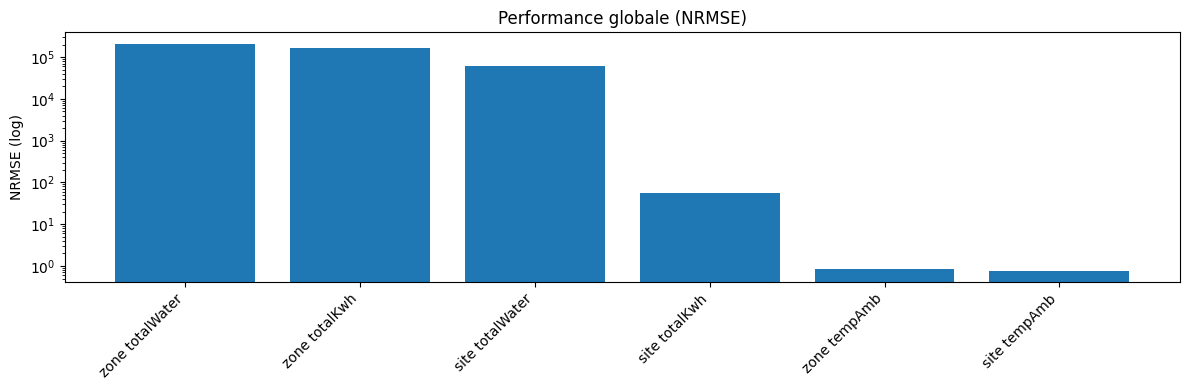

In [12]:
# 1) Overview: NRMSE bar chart (log scale)
d = summary2.copy()
d = d[np.isfinite(d['NRMSE']) & (d['NRMSE'] > 0)].copy()

d['label'] = d['level'] + ' ' + d['pred_col']
d = d.sort_values('NRMSE', ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(d['label'], d['NRMSE'])
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('NRMSE (log)')
plt.title('Performance globale (NRMSE)')
savefig('01_nrmse_overview.png')
plt.show()

saved output\figures\02_bias_vs_rmse.png


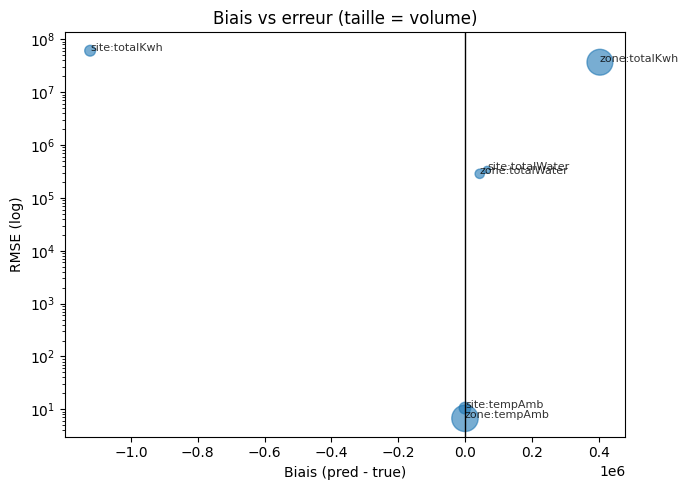

In [13]:
# 2) Bias vs RMSE scatter (bubble size = n)
d = summary2.copy()
d = d[np.isfinite(d['RMSE']) & np.isfinite(d['Bias(pred-true)']) & np.isfinite(d['n'])].copy()

plt.figure(figsize=(7, 5))
sizes = np.clip(d['n'].to_numpy(dtype=float) / 50.0, 10, 600)
plt.scatter(d['Bias(pred-true)'], d['RMSE'], s=sizes, alpha=0.6)
for _, r in d.iterrows():
    plt.annotate(f"{r['level']}:{r['pred_col']}", (r['Bias(pred-true)'], r['RMSE']), fontsize=8, alpha=0.8)
plt.axvline(0, color='k', linewidth=1)
plt.yscale('log')
plt.xlabel('Biais (pred - true)')
plt.ylabel('RMSE (log)')
plt.title('Biais vs erreur (taille = volume)')
savefig('02_bias_vs_rmse.png')
plt.show()

saved output\figures\03_calibration_site_totalKwh.png


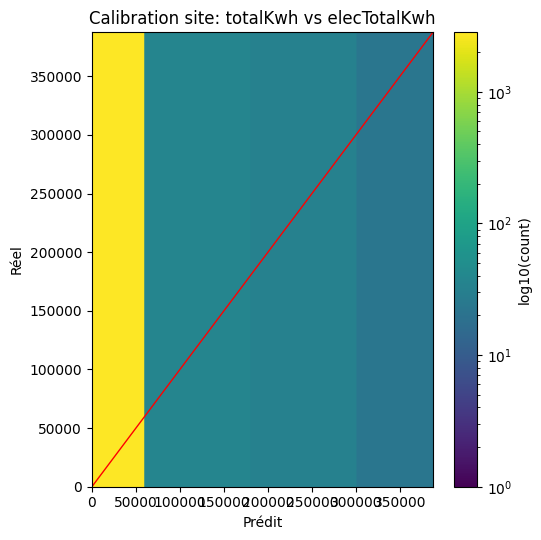

saved output\figures\04_calibration_zone_totalKwh.png


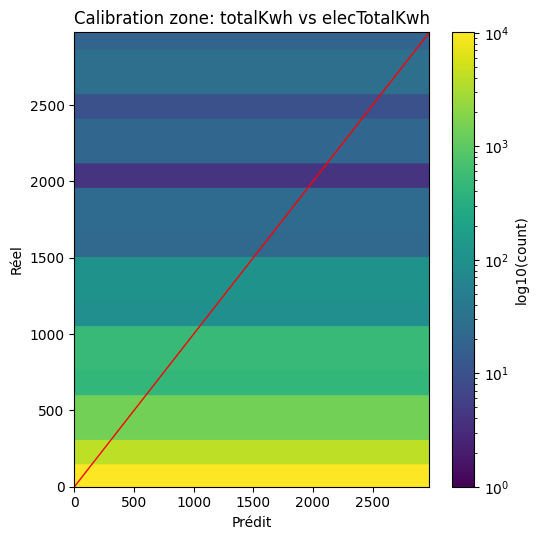

saved output\figures\05_calibration_zone_tempAmb.png


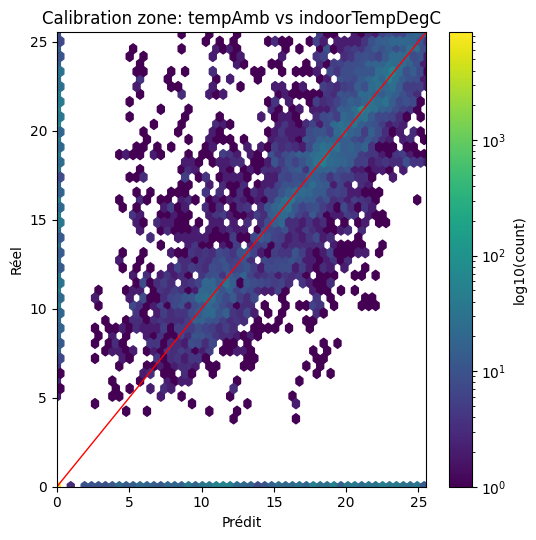

In [14]:
# 3) Calibration scatter: pred vs true (sample) for key metrics
rng = np.random.default_rng(0)

def calibration_plot(df, pred_col, true_col, title, fname, sample=20000):
    x = pd.to_numeric(df[pred_col], errors='coerce').to_numpy(dtype=float)
    y = pd.to_numeric(df[true_col], errors='coerce').to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) == 0:
        return
    if len(x) > sample:
        idx = rng.choice(len(x), size=sample, replace=False)
        x = x[idx]
        y = y[idx]
    lim = np.nanpercentile(np.concatenate([x, y]), 99)
    lim = float(lim) if np.isfinite(lim) and lim > 0 else float(np.nanmax(np.concatenate([x, y])))
    lim = max(lim, 1e-9)
    plt.figure(figsize=(5.5, 5.5))
    plt.hexbin(x, y, gridsize=60, bins='log', mincnt=1)
    plt.plot([0, lim], [0, lim], color='r', linewidth=1)
    plt.xlim(0, lim)
    plt.ylim(0, lim)
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(title)
    cb = plt.colorbar()
    cb.set_label('log10(count)')
    savefig(fname)
    plt.show()

if 'totalKwh' in SITE_MAP:
    calibration_plot(site_base, 'totalKwh', 'elecTotalKwh', 'Calibration site: totalKwh vs elecTotalKwh', '03_calibration_site_totalKwh.png')
if 'totalKwh' in ZONE_MAP:
    calibration_plot(zone_base, 'totalKwh', 'elecTotalKwh', 'Calibration zone: totalKwh vs elecTotalKwh', '04_calibration_zone_totalKwh.png')
if 'tempAmb' in ZONE_MAP:
    calibration_plot(zone_base, 'tempAmb', 'indoorTempDegC', 'Calibration zone: tempAmb vs indoorTempDegC', '05_calibration_zone_tempAmb.png')

saved output\figures\06_residuals_zone_tempAmb.png


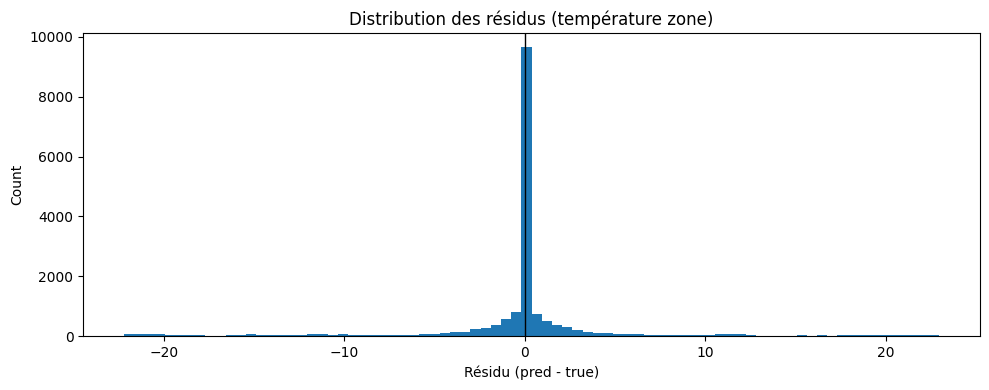

In [15]:
# 4) Residual distribution for temperature (zone)
if 'tempAmb' in ZONE_MAP:
    x = pd.to_numeric(zone_base['tempAmb'], errors='coerce')
    y = pd.to_numeric(zone_base['indoorTempDegC'], errors='coerce')
    m = x.notna() & y.notna()
    res = (x[m] - y[m]).to_numpy(dtype=float)
    if len(res):
        p1, p99 = np.nanpercentile(res, [1, 99])
        plt.figure(figsize=(10, 4))
        plt.hist(res, bins=80, range=(p1, p99))
        plt.axvline(0, color='k', linewidth=1)
        plt.xlabel('Résidu (pred - true)')
        plt.ylabel('Count')
        plt.title('Distribution des résidus (température zone)')
        savefig('06_residuals_zone_tempAmb.png')
        plt.show()

In [16]:
# 5) Site 130 time series with gap shading and spike markers (kWh)
SITE_FOCUS = 130

if set(['siteId', 'date', 'elecTotalKwh']).issubset(sitehist_raw.columns) and set(['siteId', 'dtUpdate', 'elecTotalKwh']).issubset(sitehist_raw.columns):
    hraw = sitehist_raw.copy()
    if 'date' not in hraw.columns and 'dtUpdate' in hraw.columns:
        hraw['date'] = pd.to_datetime(hraw['dtUpdate'], errors='coerce').dt.floor('D')
    hraw['siteId'] = pd.to_numeric(hraw['siteId'], errors='coerce').astype('Int64')
    hraw = hraw[hraw['siteId'] == SITE_FOCUS].copy()
    hraw['elecTotalKwh'] = pd.to_numeric(hraw['elecTotalKwh'], errors='coerce')
    hraw = hraw.dropna(subset=['date']).sort_values('date')

    hcln = sitehist[sitehist['siteId'] == SITE_FOCUS].copy()
    hcln['elecTotalKwh'] = pd.to_numeric(hcln.get('elecTotalKwh'), errors='coerce')
    hcln = hcln.dropna(subset=['date']).sort_values('date')

    p = sitepred[sitepred['siteId'] == SITE_FOCUS].copy()
    if 'date' in p.columns and 'totalKwh' in p.columns:
        p['totalKwh'] = pd.to_numeric(p['totalKwh'], errors='coerce')
        p = p.dropna(subset=['date']).sort_values('date')

    plt.figure(figsize=(12, 4))
    plt.plot(hraw['date'], hraw['elecTotalKwh'], color='#999999', linewidth=1, label='hist raw')
    plt.plot(hcln['date'], hcln['elecTotalKwh'], color='#1f77b4', linewidth=1.5, label='hist cleaned')
    if len(p):
        plt.plot(p['date'], p['totalKwh'], color='#ff7f0e', linewidth=1.2, label='pred totalKwh')

    if len(gaps):
        gk = gaps[(gaps['siteId'] == SITE_FOCUS) & (gaps['value_col'] == 'elecTotalKwh')]
        for _, r in gk.iterrows():
            a = pd.to_datetime(r['gap_start'])
            b = pd.to_datetime(r['gap_end'])
            plt.axvspan(a, b, color='red', alpha=0.08)

    key = 'sitehist_cumul_elecTotalKwh'
    if key in CLEAN_LOGS and len(CLEAN_LOGS[key]):
        cl = CLEAN_LOGS[key]
        cl = cl[cl['group'].astype(str).str.contains('130')].copy()
        if len(cl):
            dates = pd.to_datetime(cl['date'], errors='coerce')
            ys = [hcln.loc[hcln['date'] == d, 'elecTotalKwh'].iloc[0] if (hcln['date'] == d).any() else np.nan for d in dates]
            plt.scatter(dates, ys, color='red', s=35, label='cumul detected')

    plt.yscale('log')
    plt.title('Site 130: elecTotalKwh (raw vs cleaned) + prédiction + gaps')
    plt.xlabel('Date')
    plt.ylabel('kWh (log)')
    plt.legend(loc='upper right')
    savefig('07_site130_timeseries_kwh.png')
    plt.show()

saved output\figures\08_top_sites_rmse_totalKwh.png


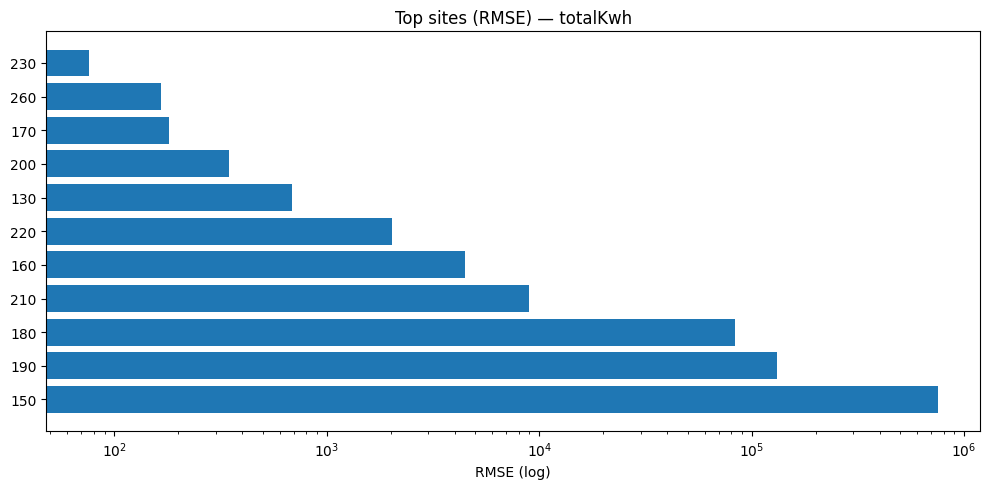

saved output\figures\09_top_sites_rmse_totalWater.png


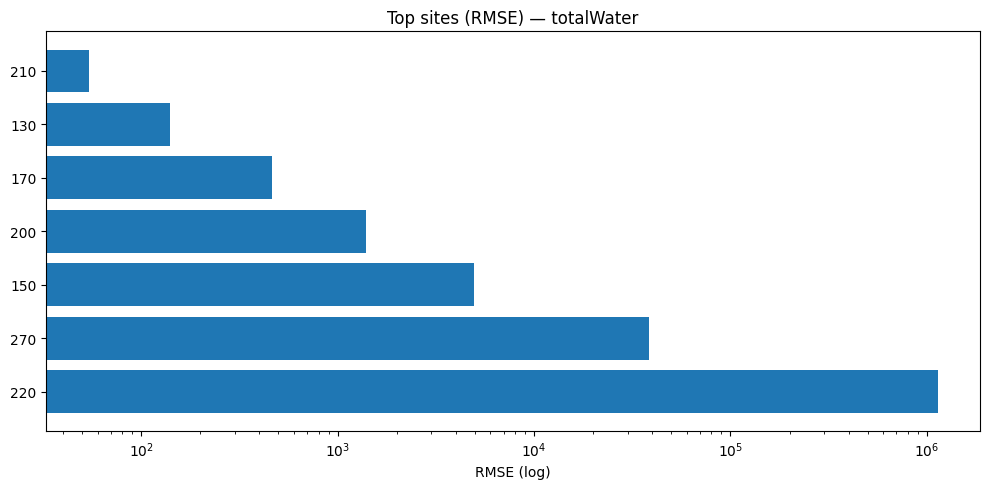

In [17]:
# 6) Heatmap-like view: RMSE by site for totalKwh/totalWater (top 25 worst)

def rmse_table(metric_key, df, top=25, nmin=30):
    if metric_key not in df:
        return None
    d = df[metric_key].copy()
    d['n'] = pd.to_numeric(d['n'], errors='coerce')
    d['RMSE'] = pd.to_numeric(d['RMSE'], errors='coerce')
    d = d[(d['n'] >= nmin) & np.isfinite(d['RMSE'])]
    return d.sort_values('RMSE', ascending=False).head(top)

kwh = rmse_table('totalKwh', site_by_site, top=25, nmin=30)
wat = rmse_table('totalWater', site_by_site, top=25, nmin=10)

if kwh is not None:
    plt.figure(figsize=(10, 5))
    y = kwh['siteId'].astype(str)
    x = kwh['RMSE'].to_numpy(dtype=float)
    plt.barh(y, x)
    plt.xscale('log')
    plt.xlabel('RMSE (log)')
    plt.title('Top sites (RMSE) — totalKwh')
    savefig('08_top_sites_rmse_totalKwh.png')
    plt.show()

if wat is not None:
    plt.figure(figsize=(10, 5))
    y = wat['siteId'].astype(str)
    x = wat['RMSE'].to_numpy(dtype=float)
    plt.barh(y, x)
    plt.xscale('log')
    plt.xlabel('RMSE (log)')
    plt.title('Top sites (RMSE) — totalWater')
    savefig('09_top_sites_rmse_totalWater.png')
    plt.show()

,action,count
0,zonehist_unit_elecTotalKwh,52
15,zonehist_cumul_elecAggregatedKwh,35
9,zonehist_cumul_elecTotalKwh,28
11,zonehist_cumul_elecCvcKwh,24
14,zonehist_cumul_elecForceKwh,14
8,sitehist_cumul_elecAggregatedKwh,11
2,sitehist_cumul_elecTotalKwh,10
10,zonehist_cumul_waterM3,8
13,zonehist_cumul_elecLightingKwh,7
4,sitehist_cumul_elecCvcKwh,7


saved output\figures\10_cleaning_actions_counts.png


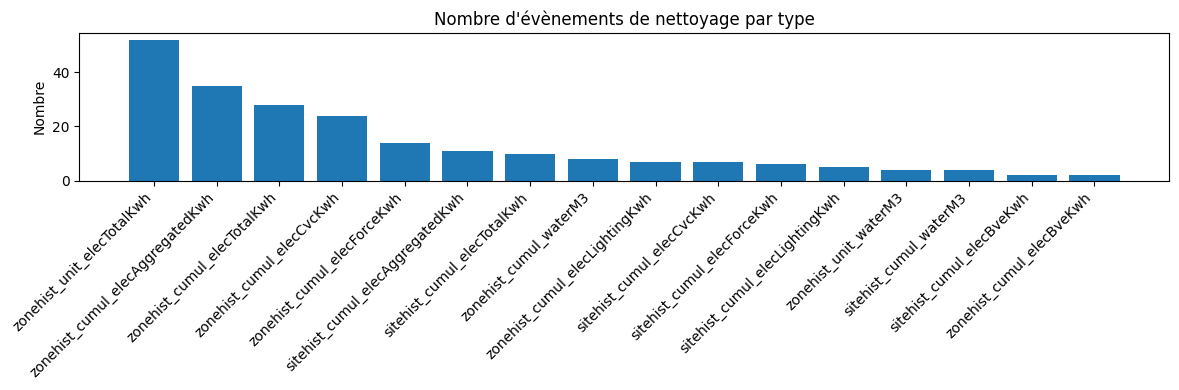

In [19]:
# 7) Data quality dashboard: counts of cleaning actions
counts = []
for k, df in CLEAN_LOGS.items():
    counts.append({'action': k, 'count': int(len(df))})
counts = pd.DataFrame(counts).sort_values('count', ascending=False)
display(counts)

plt.figure(figsize=(12, 4))
plt.bar(counts['action'], counts['count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Nombre')
plt.title("Nombre d'évènements de nettoyage par type")
savefig('10_cleaning_actions_counts.png')
plt.show()

saved output\figures\11_top_gaps.png


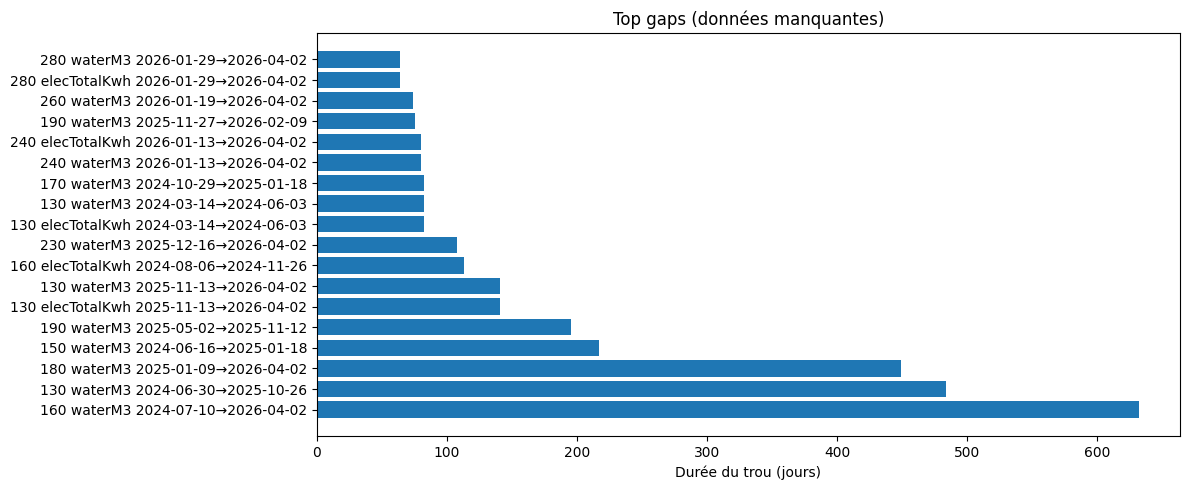

In [20]:
# 8) Gap severity: top gaps by duration
if len(gaps):
    g = gaps.head(20).copy()
    labels = g['siteId'].astype(str) + ' ' + g['value_col'] + ' ' + g['gap_start'] + '→' + g['gap_end']
    plt.figure(figsize=(12, 5))
    plt.barh(labels, g['gap_days'].to_numpy(dtype=float))
    plt.xlabel('Durée du trou (jours)')
    plt.title('Top gaps (données manquantes)')
    savefig('11_top_gaps.png')
    plt.show()

saved output\figures\12_rolling_abs_error_temp_site.png


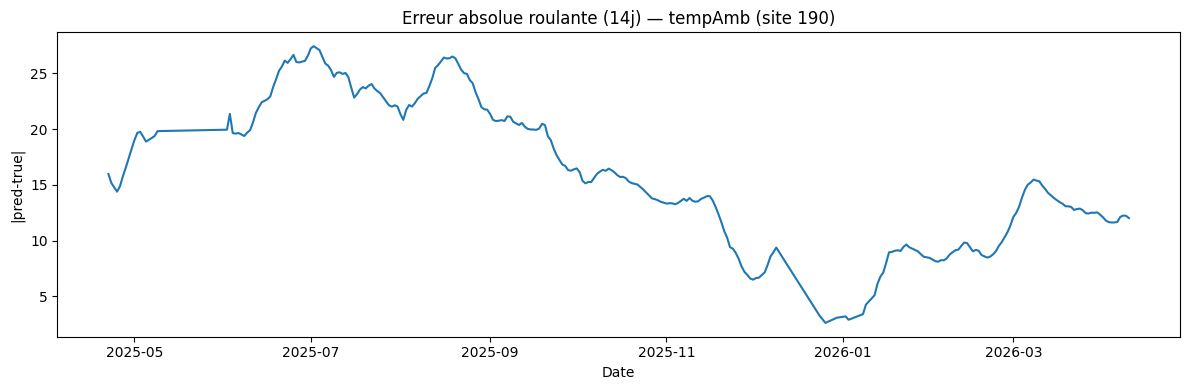

In [21]:
# 9) Time series error: rolling absolute error for site temperature (where available)
if 'tempAmb' in SITE_MAP:
    if 'tempAmb' in site_base.columns and 'weath_tempAmb' in site_base.columns:
        d = site_base.dropna(subset=['siteId', 'date', 'tempAmb', 'weath_tempAmb']).copy()
        d['err'] = (pd.to_numeric(d['tempAmb'], errors='coerce') - pd.to_numeric(d['weath_tempAmb'], errors='coerce')).abs()
        d = d.dropna(subset=['err'])
        sid = int(d.groupby('siteId')['err'].mean().sort_values(ascending=False).index[0]) if len(d) else None
        if sid is not None:
            s = d[d['siteId'] == sid].sort_values('date')
            s = s.set_index('date')['err'].rolling('14D').mean().reset_index()
            plt.figure(figsize=(12, 4))
            plt.plot(s['date'], s['err'])
            plt.title(f'Erreur absolue roulante (14j) — tempAmb (site {sid})')
            plt.xlabel('Date')
            plt.ylabel('|pred-true|')
            savefig('12_rolling_abs_error_temp_site.png')
            plt.show()

In [22]:
# Notes: figures are saved to output/figures
print('FIG_DIR =', FIG_DIR)

FIG_DIR = output\figures
